In [11]:
# ============================================================================
# ALGORITMO GENÉTICO PARA OTIMIZAÇÃO DE HIPERPARÂMETROS DE ANN
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Algoritmo Genético
import pygad
import pygad.kerasga

# Configurações
tf.random.set_seed(42)
np.random.seed(42)

print("=" * 80)
print("ALGORITMO GENÉTICO PARA OTIMIZAÇÃO DE HIPERPARÂMETROS DE ANN")
print("Objetivo: Encontrar a melhor arquitetura para predição de pré-tratamento hidrotérmico")
print("=" * 80)

print("\n✓ Bibliotecas importadas com sucesso!")
print(f"✓ TensorFlow versão: {tf.__version__}")
print(f"✓ Numpy versão: {np.__version__}")
print(f"✓ Pandas versão: {pd.__version__}")

ALGORITMO GENÉTICO PARA OTIMIZAÇÃO DE HIPERPARÂMETROS DE ANN
Objetivo: Encontrar a melhor arquitetura para predição de pré-tratamento hidrotérmico

✓ Bibliotecas importadas com sucesso!
✓ TensorFlow versão: 2.18.0
✓ Numpy versão: 1.26.4
✓ Pandas versão: 2.2.3


In [12]:
# ============================================================================
# 1. CARREGAMENTO E ANÁLISE DOS DADOS SINTÉTICOS
# ============================================================================

print("\n1. CARREGANDO DADOS SINTÉTICOS...")

# Carregar dados sintéticos gerados com LHS
data_path = '../../../Pretreatment/Data Generation/synthetic_pretreatment_data_LHS.csv'
df = pd.read_csv(data_path)

# Limpar nomes das colunas (remover espaços extras)
df.columns = df.columns.str.strip()

print(f"✓ Dados carregados: {df.shape[0]} amostras, {df.shape[1]} colunas")
print(f"✓ Colunas: {list(df.columns)}")

# Verificar estrutura dos dados
print(f"\n📊 ANÁLISE DA ESTRUTURA DOS DADOS:")
print(f"   • Total de linhas: {len(df)}")

# Identificar condições únicas (Temperature, Cellulose Fraction, Hemicellulose Fraction, Lignin Fraction, Solids Loading)
condition_columns = ['Temperature [°C]', 'Cellulose Fraction', 'Hemicellulose Fraction', 'Lignin Fraction', 'Solids Loading [g/L]']
unique_conditions = df[condition_columns].drop_duplicates()
n_conditions = len(unique_conditions)

print(f"   • Número de condições únicas: {n_conditions}")
print(f"   • Tempos por condição: {len(df) // n_conditions}")

# Verificar se cada condição tem exatamente 7 tempos
time_points = df['Time [min]'].unique()
print(f"   • Tempos únicos: {sorted(time_points)}")

# Mostrar exemplo de uma condição
print(f"\n📋 EXEMPLO DE UMA CONDIÇÃO (primeiras 7 linhas):")
first_condition = df.head(7)[['Temperature [°C]', 'Cellulose Fraction', 'Hemicellulose Fraction', 
                               'Lignin Fraction', 'Solids Loading [g/L]', 'Time [min]',
                               'Cellulose Remaining [g/L]', 'Hemicellulose Remaining [g/L]']]
print(first_condition.to_string(index=False, float_format='%.3f'))

# Estatísticas dos produtos
print(f"\n📈 ESTATÍSTICAS DOS PRODUTOS:")
products = ['Cellulose Remaining [g/L]', 'Hemicellulose Remaining [g/L]']
for product in products:
    mean_val = df[product].mean()
    std_val = df[product].std()
    min_val = df[product].min()
    max_val = df[product].max()
    print(f"   • {product.replace(' Remaining [g/L]', '')}: {min_val:.2f} - {max_val:.2f} (μ={mean_val:.2f}, σ={std_val:.2f})")

print(f"\n✅ Dados analisados. Pronto para divisão em conjuntos de treino/validação/teste!")


1. CARREGANDO DADOS SINTÉTICOS...
✓ Dados carregados: 1400 amostras, 8 colunas
✓ Colunas: ['Temperature [°C]', 'Cellulose Fraction', 'Hemicellulose Fraction', 'Lignin Fraction', 'Solids Loading [g/L]', 'Time [min]', 'Cellulose Remaining [g/L]', 'Hemicellulose Remaining [g/L]']

📊 ANÁLISE DA ESTRUTURA DOS DADOS:
   • Total de linhas: 1400
   • Número de condições únicas: 200
   • Tempos por condição: 7
   • Tempos únicos: [0, 5, 10, 15, 20, 30, 40]

📋 EXEMPLO DE UMA CONDIÇÃO (primeiras 7 linhas):
 Temperature [°C]  Cellulose Fraction  Hemicellulose Fraction  Lignin Fraction  Solids Loading [g/L]  Time [min]  Cellulose Remaining [g/L]  Hemicellulose Remaining [g/L]
          182.168               0.380                   0.296            0.324                91.561           0                     34.819                         27.098
          182.168               0.380                   0.296            0.324                91.561           5                     33.686                 

In [13]:
# ============================================================================
# 2. DIVISÃO ESTRATÉGICA DOS DADOS POR CONDIÇÕES
# ============================================================================

print("\n2. DIVIDINDO DADOS POR CONDIÇÕES...")

# Identificar todas as condições únicas
condition_columns = ['Temperature [°C]', 'Cellulose Fraction', 'Hemicellulose Fraction', 'Lignin Fraction', 'Solids Loading [g/L]']
unique_conditions = df[condition_columns].drop_duplicates().reset_index(drop=True)
n_conditions = len(unique_conditions)

print(f"✓ Total de condições identificadas: {n_conditions}")

# Dividir condições: 70% para otimização genética, 30% para teste final
np.random.seed(42)
condition_indices = np.arange(n_conditions)
np.random.shuffle(condition_indices)

# 70% condições para otimização (treino + validação)
n_optimization = int(0.7 * n_conditions)
optimization_condition_indices = condition_indices[:n_optimization]

# 30% condições para teste final
test_condition_indices = condition_indices[n_optimization:]

print(f"✓ Condições para otimização: {len(optimization_condition_indices)} ({len(optimization_condition_indices)/n_conditions*100:.1f}%)")
print(f"✓ Condições para teste final: {len(test_condition_indices)} ({len(test_condition_indices)/n_conditions*100:.1f}%)")

# Função para extrair dados de condições específicas
def extract_conditions_data(df, condition_indices, unique_conditions):
    """Extrai todas as linhas correspondentes às condições especificadas"""
    condition_data = []
    
    for idx in condition_indices:
        condition = unique_conditions.iloc[idx]
        
        # Filtrar dados para esta condição específica
        condition_mask = True
        for col in condition_columns:
            condition_mask = condition_mask & (df[col] == condition[col])
        
        condition_rows = df[condition_mask].copy()
        condition_data.append(condition_rows)
    
    return pd.concat(condition_data, ignore_index=True)

# Extrair dados de otimização (70% das condições)
optimization_data = extract_conditions_data(df, optimization_condition_indices, unique_conditions)

# Extrair dados de teste final (30% das condições)
test_data = extract_conditions_data(df, test_condition_indices, unique_conditions)

print(f"\n📊 VERIFICAÇÃO DA DIVISÃO:")
print(f"   • Dados de otimização: {len(optimization_data)} amostras de {len(optimization_condition_indices)} condições")
print(f"   • Dados de teste final: {len(test_data)} amostras de {len(test_condition_indices)} condições")
print(f"   • Total: {len(optimization_data) + len(test_data)} amostras (deve ser igual a {len(df)})")

# Verificar que não há sobreposição entre os conjuntos
optimization_conditions = set()
for idx in optimization_condition_indices:
    condition = unique_conditions.iloc[idx]
    condition_tuple = tuple(condition[col] for col in condition_columns)
    optimization_conditions.add(condition_tuple)

test_conditions = set()
for idx in test_condition_indices:
    condition = unique_conditions.iloc[idx]
    condition_tuple = tuple(condition[col] for col in condition_columns)
    test_conditions.add(condition_tuple)

overlap = optimization_conditions.intersection(test_conditions)
print(f"   • Sobreposição entre conjuntos: {len(overlap)} (deve ser 0)")

if len(overlap) == 0:
    print("✅ Divisão por condições realizada com sucesso!")
else:
    print("❌ Erro: Há sobreposição entre os conjuntos!")

# Salvar índices para reprodutibilidade
print(f"\n📝 ÍNDICES DAS CONDIÇÕES:")
print(f"   • Otimização: {sorted(optimization_condition_indices)}")
print(f"   • Teste final: {sorted(test_condition_indices)}")


2. DIVIDINDO DADOS POR CONDIÇÕES...
✓ Total de condições identificadas: 200
✓ Condições para otimização: 140 (70.0%)
✓ Condições para teste final: 60 (30.0%)

📊 VERIFICAÇÃO DA DIVISÃO:
   • Dados de otimização: 980 amostras de 140 condições
   • Dados de teste final: 420 amostras de 60 condições
   • Total: 1400 amostras (deve ser igual a 1400)
   • Sobreposição entre conjuntos: 0 (deve ser 0)
✅ Divisão por condições realizada com sucesso!

📝 ÍNDICES DAS CONDIÇÕES:
   • Otimização: [0, 2, 3, 4, 5, 6, 9, 10, 11, 12, 15, 16, 18, 19, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 35, 36, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 51, 53, 55, 56, 60, 61, 62, 64, 65, 66, 67, 68, 69, 70, 73, 75, 76, 77, 78, 79, 81, 82, 84, 85, 86, 90, 93, 94, 95, 96, 97, 98, 100, 101, 104, 105, 108, 109, 111, 112, 113, 114, 115, 117, 118, 119, 120, 122, 123, 124, 125, 126, 127, 128, 132, 133, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 150, 152, 153, 154, 155, 156, 158, 159, 161, 162

In [14]:
# ============================================================================
# 3. PREPARAÇÃO DOS DADOS PARA MACHINE LEARNING
# ============================================================================

print("\n3. PREPARANDO DADOS PARA MACHINE LEARNING...")

# Definir features de entrada e saída
input_features = ['Temperature [°C]', 'Cellulose Fraction', 'Hemicellulose Fraction', 'Lignin Fraction', 'Solids Loading [g/L]', 'Time [min]']
output_features = ['Cellulose Remaining [g/L]', 'Hemicellulose Remaining [g/L]']

print(f"✓ Features de entrada ({len(input_features)}): {input_features}")
print(f"✓ Features de saída ({len(output_features)}): {output_features}")

# Dividir dados de otimização em treino (60%) e validação (10%)
# Novamente dividindo por condições completas
optimization_conditions = unique_conditions.iloc[optimization_condition_indices].reset_index(drop=True)
n_opt_conditions = len(optimization_conditions)

# 60% das condições totais para treino (6/7 das condições de otimização)
n_train = int(0.6 * n_conditions)
n_val = len(optimization_condition_indices) - n_train

# Dividir condições de otimização
np.random.seed(42)
opt_indices = np.arange(len(optimization_condition_indices))
np.random.shuffle(opt_indices)

train_condition_indices = [optimization_condition_indices[i] for i in opt_indices[:n_train]]
val_condition_indices = [optimization_condition_indices[i] for i in opt_indices[n_train:]]

print(f"\n📊 DIVISÃO FINAL DOS DADOS:")
print(f"   • Treino: {len(train_condition_indices)} condições ({len(train_condition_indices)/n_conditions*100:.1f}% do total)")
print(f"   • Validação: {len(val_condition_indices)} condições ({len(val_condition_indices)/n_conditions*100:.1f}% do total)")
print(f"   • Teste final: {len(test_condition_indices)} condições ({len(test_condition_indices)/n_conditions*100:.1f}% do total)")

# Extrair dados de treino e validação
train_data = extract_conditions_data(df, train_condition_indices, unique_conditions)
val_data = extract_conditions_data(df, val_condition_indices, unique_conditions)

print(f"\n📈 AMOSTRAS POR CONJUNTO:")
print(f"   • Treino: {len(train_data)} amostras")
print(f"   • Validação: {len(val_data)} amostras")
print(f"   • Teste final: {len(test_data)} amostras")
print(f"   • Total: {len(train_data) + len(val_data) + len(test_data)} amostras")

# Preparar arrays para ML
X_train = train_data[input_features].values
y_train = train_data[output_features].values

X_val = val_data[input_features].values
y_val = val_data[output_features].values

X_test = test_data[input_features].values
y_test = test_data[output_features].values

print(f"\n🔢 DIMENSÕES DOS ARRAYS:")
print(f"   • X_train: {X_train.shape}")
print(f"   • y_train: {y_train.shape}")
print(f"   • X_val: {X_val.shape}")
print(f"   • y_val: {y_val.shape}")
print(f"   • X_test: {X_test.shape}")
print(f"   • y_test: {y_test.shape}")

# Normalizar dados com MinMaxScaler (Solução 4 - evita valores negativos)
print(f"\n⚖️  NORMALIZANDO DADOS COM MINMAXSCALER...")
from sklearn.preprocessing import MinMaxScaler

# Usar MinMaxScaler em vez de StandardScaler para manter valores positivos
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))  # Evita predições negativas

# Ajustar escaladores apenas nos dados de treino
X_train_scaled = scaler_X.fit_transform(X_train)
y_train_scaled = scaler_y.fit_transform(y_train)

# Aplicar mesma normalização aos dados de validação e teste
X_val_scaled = scaler_X.transform(X_val)
y_val_scaled = scaler_y.transform(y_val)

X_test_scaled = scaler_X.transform(X_test)
y_test_scaled = scaler_y.transform(y_test)

print(f"✓ Normalização MinMaxScaler aplicada usando parâmetros do conjunto de treino")

# Verificar normalização MinMaxScaler
print(f"\n📊 VERIFICAÇÃO DA NORMALIZAÇÃO MINMAX (treino):")
print(f"   • X_train - Min: {X_train_scaled.min(axis=0).round(3)}")
print(f"   • X_train - Max: {X_train_scaled.max(axis=0).round(3)}")
print(f"   • y_train - Min: {y_train_scaled.min(axis=0).round(3)}")
print(f"   • y_train - Max: {y_train_scaled.max(axis=0).round(3)}")

print(f"\n✅ Dados preparados e normalizados com MinMaxScaler (evita valores negativos)!")


3. PREPARANDO DADOS PARA MACHINE LEARNING...
✓ Features de entrada (6): ['Temperature [°C]', 'Cellulose Fraction', 'Hemicellulose Fraction', 'Lignin Fraction', 'Solids Loading [g/L]', 'Time [min]']
✓ Features de saída (2): ['Cellulose Remaining [g/L]', 'Hemicellulose Remaining [g/L]']

📊 DIVISÃO FINAL DOS DADOS:
   • Treino: 120 condições (60.0% do total)
   • Validação: 20 condições (10.0% do total)
   • Teste final: 60 condições (30.0% do total)

📈 AMOSTRAS POR CONJUNTO:
   • Treino: 840 amostras
   • Validação: 140 amostras
   • Teste final: 420 amostras
   • Total: 1400 amostras

🔢 DIMENSÕES DOS ARRAYS:
   • X_train: (840, 6)
   • y_train: (840, 2)
   • X_val: (140, 6)
   • y_val: (140, 2)
   • X_test: (420, 6)
   • y_test: (420, 2)

⚖️  NORMALIZANDO DADOS COM MINMAXSCALER...
✓ Normalização MinMaxScaler aplicada usando parâmetros do conjunto de treino

📊 VERIFICAÇÃO DA NORMALIZAÇÃO MINMAX (treino):
   • X_train - Min: [0. 0. 0. 0. 0. 0.]
   • X_train - Max: [1. 1. 1. 1. 1. 1.]
   

In [15]:
# ============================================================================
# 4. DEFINIÇÃO DA ARQUITETURA ANN E FUNÇÃO DE FITNESS SUPER-OTIMIZADA
# ============================================================================

print("\n4. DEFININDO ARQUITETURA ANN E FUNÇÃO DE FITNESS SUPER-OTIMIZADA...")

# Parâmetros fixos da arquitetura
INPUT_DIM = 6  # 6 features de entrada
OUTPUT_DIM = 2  # 2 produtos de saída (PRETREATMENT!)
N_HIDDEN_LAYERS = 3  # 3 camadas ocultas (fixo)
ACTIVATION = 'relu'  # Função de ativação (fixo)
OPTIMIZER = 'adam'  # Otimizador (fixo)

# Hiperparâmetros variáveis (genes)
NEURONS_LAYER1_OPTIONS = [16, 32, 48, 64]    # Opções para camada 1
NEURONS_LAYER2_OPTIONS = [16, 32, 48, 64]    # Opções para camada 2  
NEURONS_LAYER3_OPTIONS = [8, 16, 24, 32]     # Opções para camada 3

print(f"✓ Parâmetros fixos:")
print(f"   • Input: {INPUT_DIM} features")
print(f"   • Output: {OUTPUT_DIM} produtos (Cellulose + Hemicellulose Remaining)")
print(f"   • Hidden layers: {N_HIDDEN_LAYERS}")
print(f"   • Ativação: {ACTIVATION}")
print(f"   • Otimizador: {OPTIMIZER}")

print(f"\n✓ Hiperparâmetros variáveis (genes):")
print(f"   • Camada 1: {NEURONS_LAYER1_OPTIONS} neurônios")
print(f"   • Camada 2: {NEURONS_LAYER2_OPTIONS} neurônios") 
print(f"   • Camada 3: {NEURONS_LAYER3_OPTIONS} neurônios")

# ============================================================================
# 🎯 ESTRATÉGIA 1: CONSTRAINT FÍSICO NA PREDIÇÃO (ADAPTADO PARA PRETREATMENT)
# ============================================================================

print(f"\n🎯 IMPLEMENTANDO ESTRATÉGIA 1: CONSTRAINT FÍSICO PARA PRÉ-TRATAMENTO!")

def apply_physical_constraints(predictions, time_inputs, cellulose_fractions, hemicellulose_fractions, solids_loadings):
    """
    Aplica constraints físicos às predições de pré-tratamento hidrotérmico.
    
    PRETREATMENT: Em t=0min, as concentrações devem ser iguais às iniciais:
    - C0 = solids_loading × cellulose_fraction
    - H0 = solids_loading × hemicellulose_fraction
    
    Para t>0min: concentrações remaining devem ser ≤ iniciais (degradação)
    
    Parameters:
    -----------
    predictions : np.array
        Predições da ANN (shape: [n_samples, 2])
    time_inputs : np.array
        Valores de tempo em minutos (shape: [n_samples,])
    cellulose_fractions : np.array
        Frações de celulose (0-1) (shape: [n_samples,])
    hemicellulose_fractions : np.array
        Frações de hemicelulose (0-1) (shape: [n_samples,])
    solids_loadings : np.array
        Carregamento de sólidos em g/L (shape: [n_samples,])
        
    Returns:
    --------
    constrained_predictions : np.array
        Predições com constraints aplicados
    """
    # Copiar predições para não modificar o original
    constrained_predictions = predictions.copy()
    
    # Calcular concentrações iniciais
    C0 = solids_loadings * cellulose_fractions
    H0 = solids_loadings * hemicellulose_fractions
    
    # Identificar amostras t=0min (tolerância para comparações float)
    tolerance = 1e-6
    t0_mask = np.abs(time_inputs) < tolerance
    
    # Aplicar constraint: t=0min → [C0, H0]
    if np.any(t0_mask):
        constrained_predictions[t0_mask, 0] = C0[t0_mask]  # Cellulose
        constrained_predictions[t0_mask, 1] = H0[t0_mask]  # Hemicellulose
        
        n_t0_samples = np.sum(t0_mask)
        print(f"   ✅ Constraint t=0min aplicado em {n_t0_samples} amostras: [C0, H0]")
    
    # Para t>0: garantir que remaining ≤ inicial (não pode aumentar)
    constrained_predictions[:, 0] = np.minimum(constrained_predictions[:, 0], C0)
    constrained_predictions[:, 1] = np.minimum(constrained_predictions[:, 1], H0)
    
    # Garantir valores não-negativos
    constrained_predictions = np.maximum(constrained_predictions, 0.0)
    
    return constrained_predictions

def predict_with_constraints(model, X_scaled, X_original, scaler_y):
    """
    Função de predição que aplica constraints físicos de pré-tratamento automaticamente.
    
    Parameters:
    -----------
    model : keras.Model
        Modelo treinado
    X_scaled : np.array
        Features normalizadas
    X_original : np.array
        Features originais (para extrair dados)
    scaler_y : MinMaxScaler
        Scaler para desnormalizar predições
        
    Returns:
    --------
    predictions_constrained : np.array
        Predições com constraints físicos aplicados
    """
    # Fazer predições normalizadas
    y_pred_scaled = model.predict(X_scaled, verbose=0)
    
    # Desnormalizar predições
    y_pred = scaler_y.inverse_transform(y_pred_scaled)
    
    # Extrair dados necessários das features originais
    # Ordem: ['Temperature [°C]', 'Cellulose Fraction', 'Hemicellulose Fraction', 
    #         'Lignin Fraction', 'Solids Loading [g/L]', 'Time [min]']
    cellulose_fractions = X_original[:, 1]      # Index 1
    hemicellulose_fractions = X_original[:, 2]  # Index 2
    solids_loadings = X_original[:, 4]          # Index 4
    time_values = X_original[:, 5]              # Index 5 (Time [min])
    
    # Aplicar constraints físicos
    y_pred_constrained = apply_physical_constraints(
        y_pred, time_values, cellulose_fractions, hemicellulose_fractions, solids_loadings
    )
    
    return y_pred_constrained

print(f"✓ Estratégia 1 implementada para PRÉ-TRATAMENTO:")
print(f"   • Tipo: Constraint Físico Pós-Predição")
print(f"   • Detecção t=0min: Baseada na feature Time [min]")
print(f"   • Constraint inicial: if t=0: [C_rem, H_rem] = [C0, H0]")
print(f"   • C0 = solids_loading × cellulose_fraction")
print(f"   • H0 = solids_loading × hemicellulose_fraction")
print(f"   • Constraint degradação: remaining ≤ inicial para t>0")
print(f"   • Garantia: 100% de correção física")

# ============================================================================
# MONITORAMENTO DE CONSTRAINTS FÍSICOS (ADAPTADO PARA PRETREATMENT)
# ============================================================================

class PhysicalConstraintMonitor:
    """Classe para monitorar violações de constraints físicos de pré-tratamento"""
    
    def __init__(self):
        self.violation_history = []
        
    def check_violations(self, predictions, time_inputs, cellulose_fractions, hemicellulose_fractions, solids_loadings, description=""):
        """
        Verifica violações de constraints físicos para pré-tratamento
        
        Parameters:
        -----------
        predictions : np.array
            Predições a serem verificadas (shape: [n_samples, 2])
        time_inputs : np.array
            Valores de tempo em minutos
        cellulose_fractions : np.array
            Frações de celulose (0-1)
        hemicellulose_fractions : np.array
            Frações de hemicelulose (0-1)
        solids_loadings : np.array
            Carregamento de sólidos em g/L
        description : str
            Descrição para logging
            
        Returns:
        --------
        dict : Estatísticas das violações
        """
        # Identificar amostras t=0min
        t0_mask = np.abs(time_inputs) < 1e-6
        n_t0_samples = np.sum(t0_mask)
        
        if n_t0_samples > 0:
            # Calcular valores esperados
            C0 = solids_loadings[t0_mask] * cellulose_fractions[t0_mask]
            H0 = solids_loadings[t0_mask] * hemicellulose_fractions[t0_mask]
            
            # Calcular violações em amostras t=0min
            t0_preds = predictions[t0_mask]
            violations_C = np.abs(t0_preds[:, 0] - C0)
            violations_H = np.abs(t0_preds[:, 1] - H0)
            
            max_violation = max(np.max(violations_C), np.max(violations_H))
            mean_violation = (np.mean(violations_C) + np.mean(violations_H)) / 2
            perfect_samples = np.sum((violations_C < 1e-6) & (violations_H < 1e-6))
            
            stats = {
                'n_t0_samples': n_t0_samples,
                'max_violation': max_violation,
                'mean_violation': mean_violation,
                'perfect_samples': perfect_samples,
                'perfect_ratio': perfect_samples / n_t0_samples * 100,
                'description': description
            }
            
            self.violation_history.append(stats)
            
            if description:
                print(f"\n📊 MONITORAMENTO CONSTRAINT FÍSICO (PRÉ-TRATAMENTO) - {description}:")
                print(f"   • Amostras t=0min: {n_t0_samples}")
                print(f"   • Violação máxima: {max_violation:.6f} g/L")
                print(f"   • Violação média: {mean_violation:.6f} g/L")
                print(f"   • Amostras perfeitas: {perfect_samples}/{n_t0_samples} ({stats['perfect_ratio']:.1f}%)")
                
                if max_violation < 1e-6:
                    print(f"   ✅ PERFEITO: Todos os constraints respeitados!")
                elif max_violation < 0.01:
                    print(f"   ✅ EXCELENTE: Violações desprezíveis")
                else:
                    print(f"   ⚠️  ATENÇÃO: Violações significativas detectadas")
            
            return stats
        else:
            return {'n_t0_samples': 0, 'description': description}

# Criar monitor global
constraint_monitor = PhysicalConstraintMonitor()

print(f"✓ Monitor de constraints implementado para pré-tratamento")

def create_model(neurons_layer1, neurons_layer2, neurons_layer3):
    """
    Cria um modelo ANN com a arquitetura especificada
    
    Parameters:
    -----------
    neurons_layer1 : int
        Número de neurônios na primeira camada oculta
    neurons_layer2 : int
        Número de neurônios na segunda camada oculta
    neurons_layer3 : int
        Número de neurônios na terceira camada oculta
    
    Returns:
    --------
    model : tensorflow.keras.Model
        Modelo compilado (sem custom loss - usa MSE padrão)
    """
    model = keras.Sequential([
        # Camada de entrada implícita
        keras.layers.Dense(neurons_layer1, activation=ACTIVATION, input_shape=(INPUT_DIM,)),
        keras.layers.Dense(neurons_layer2, activation=ACTIVATION),
        keras.layers.Dense(neurons_layer3, activation=ACTIVATION),
        keras.layers.Dense(OUTPUT_DIM, activation='linear')  # Linear com MinMaxScaler
    ])
    
    # 🎯 USAR MSE PADRÃO (constraints aplicados pós-predição)
    model.compile(
        optimizer=OPTIMIZER,
        loss='mse',  # ← Loss padrão (constraints via pós-processamento)
        metrics=['mae']
    )
    
    return model

def decode_genes(genes):
    """
    Decodifica os genes em hiperparâmetros da ANN
    
    Parameters:
    -----------
    genes : list
        Lista com 3 valores inteiros [índice_layer1, índice_layer2, índice_layer3]
    
    Returns:
    --------
    tuple : (neurons_layer1, neurons_layer2, neurons_layer3)
    """
    neurons_layer1 = NEURONS_LAYER1_OPTIONS[int(genes[0])]
    neurons_layer2 = NEURONS_LAYER2_OPTIONS[int(genes[1])]
    neurons_layer3 = NEURONS_LAYER3_OPTIONS[int(genes[2])]
    
    return neurons_layer1, neurons_layer2, neurons_layer3

def fitness_function(ga_instance, solution, solution_idx):
    """
    Função de fitness com ESTRATÉGIA 1 (Constraint Físico Pós-Predição) - PRÉ-TRATAMENTO
    
    Parameters:
    -----------
    ga_instance : pygad.GA
        Instância do algoritmo genético
    solution : list
        Solução (genes) a ser avaliada
    solution_idx : int
        Índice da solução
    
    Returns:
    --------
    fitness : float
        Valor de fitness (quanto maior, melhor)
    """
    try:
        # Decodificar genes
        neurons_layer1, neurons_layer2, neurons_layer3 = decode_genes(solution)
        
        # Criar modelo com MSE padrão
        model = create_model(neurons_layer1, neurons_layer2, neurons_layer3)
        
        # ⚡ TREINAMENTO OTIMIZADO
        early_stopping = keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            verbose=0
        )
        
        history = model.fit(
            X_train_scaled, y_train_scaled,
            validation_data=(X_val_scaled, y_val_scaled),
            epochs=50,
            batch_size=32,
            callbacks=[early_stopping],
            verbose=0
        )
        
        # 🎯 FAZER PREDIÇÕES COM CONSTRAINTS FÍSICOS (Estratégia 1 - Pré-tratamento)
        y_val_pred_constrained = predict_with_constraints(
            model, X_val_scaled, X_val, scaler_y
        )
        
        # Calcular R² para cada produto (com constraints aplicados)
        r2_cellulose = r2_score(y_val[:, 0], y_val_pred_constrained[:, 0])
        r2_hemicellulose = r2_score(y_val[:, 1], y_val_pred_constrained[:, 1])
        
        # Garantir que R² negativos virem 0
        r2_cellulose = max(0, r2_cellulose)
        r2_hemicellulose = max(0, r2_hemicellulose)
        
        # Calcular fitness ponderado (pesos iguais para ambos os produtos)
        fitness = 0.5 * r2_cellulose + 0.5 * r2_hemicellulose
        
        # 🎯 VERIFICAR CONSTRAINT FÍSICO (deve ser sempre perfeito com Estratégia 1)
        time_values = X_val[:, 5]  # Time [min] é a última feature (index 5)
        cellulose_fractions = X_val[:, 1]
        hemicellulose_fractions = X_val[:, 2]
        solids_loadings = X_val[:, 4]
        
        constraint_stats = constraint_monitor.check_violations(
            y_val_pred_constrained, time_values, cellulose_fractions, 
            hemicellulose_fractions, solids_loadings, description=""
        )
        
        # Bônus por constraints perfeitos (deve ser sempre máximo com Estratégia 1)
        if constraint_stats.get('n_t0_samples', 0) > 0:
            perfect_ratio = constraint_stats.get('perfect_ratio', 0)
            constraint_bonus = 0.1 * (perfect_ratio / 100.0)  # Max bônus: 0.1
            fitness += constraint_bonus
        
        # Limpar memória
        del model, history
        keras.backend.clear_session()
        
        print(f"   Solução {solution_idx:2d}: [{neurons_layer1:3d}, {neurons_layer2:2d}, {neurons_layer3:2d}] → "
              f"R²=[{r2_cellulose:.3f}, {r2_hemicellulose:.3f}] → "
              f"Fitness: {fitness:.4f} (Estratégia 1 - Pretreatment)")
        
        return max(0.001, fitness)
        
    except Exception as e:
        print(f"   ❌ Erro na solução {solution_idx}: {str(e)[:50]}...")
        try:
            keras.backend.clear_session()
        except:
            pass
        return 0.001

# Testar a função de criação de modelo
print(f"\n🧪 TESTANDO CRIAÇÃO DE MODELO COM ESTRATÉGIA 1 (PRÉ-TRATAMENTO)...")
test_model = create_model(64, 32, 16)
print(f"✓ Modelo de teste criado com sucesso")
print(f"✓ Parâmetros: {test_model.count_params():,}")
print(f"✓ Loss function: MSE padrão (constraints via pós-processamento)")

# Testar função de predição com constraints
print(f"\n🧪 TESTANDO PREDIÇÃO COM CONSTRAINTS (PRÉ-TRATAMENTO)...")
# Criar dados de teste simples
# Ordem: Temperature, Cellulose Frac, Hemi Frac, Lignin Frac, Solids, Time
X_test_simple = np.array([[195, 0.40, 0.25, 0.35, 100, 0],    # t=0min
                         [195, 0.40, 0.25, 0.35, 100, 20]])   # t=20min
X_test_simple_scaled = scaler_X.transform(X_test_simple)

# Testar predição
y_pred_test = predict_with_constraints(test_model, X_test_simple_scaled, X_test_simple, scaler_y)
print(f"✓ Predições de teste:")
print(f"   • t=0min:  Cellulose={y_pred_test[0,0]:.2f} g/L, Hemicellulose={y_pred_test[0,1]:.2f} g/L")
print(f"   • t=20min: Cellulose={y_pred_test[1,0]:.2f} g/L, Hemicellulose={y_pred_test[1,1]:.2f} g/L")
print(f"   • Valores esperados em t=0: C0=40.0 g/L, H0=25.0 g/L")

# Limpar modelo de teste
del test_model
keras.backend.clear_session()

print(f"\n✅ ESTRATÉGIA 1 IMPLEMENTADA COM SUCESSO PARA PRÉ-TRATAMENTO!")
print(f"🎯 Características da Estratégia 1 (Pretreatment):")
print(f"   • Modelo: MSE padrão (sem custom loss)")
print(f"   • Constraint: Aplicado pós-predição via máscara")
print(f"   • Detecção t=0min: Baseada na feature Time [min]")
print(f"   • Constraint inicial: if t=0: [C_rem, H_rem] = [C0, H0]")
print(f"   • Constraint degradação: remaining ≤ inicial")
print(f"   • Garantia: 100% de correção para t=0min")
print(f"   • Vantagem: Simples, determinístico e robusto")


4. DEFININDO ARQUITETURA ANN E FUNÇÃO DE FITNESS SUPER-OTIMIZADA...
✓ Parâmetros fixos:
   • Input: 6 features
   • Output: 2 produtos (Cellulose + Hemicellulose Remaining)
   • Hidden layers: 3
   • Ativação: relu
   • Otimizador: adam

✓ Hiperparâmetros variáveis (genes):
   • Camada 1: [16, 32, 48, 64] neurônios
   • Camada 2: [16, 32, 48, 64] neurônios
   • Camada 3: [8, 16, 24, 32] neurônios

🎯 IMPLEMENTANDO ESTRATÉGIA 1: CONSTRAINT FÍSICO PARA PRÉ-TRATAMENTO!
✓ Estratégia 1 implementada para PRÉ-TRATAMENTO:
   • Tipo: Constraint Físico Pós-Predição
   • Detecção t=0min: Baseada na feature Time [min]
   • Constraint inicial: if t=0: [C_rem, H_rem] = [C0, H0]
   • C0 = solids_loading × cellulose_fraction
   • H0 = solids_loading × hemicellulose_fraction
   • Constraint degradação: remaining ≤ inicial para t>0
   • Garantia: 100% de correção física
✓ Monitor de constraints implementado para pré-tratamento

🧪 TESTANDO CRIAÇÃO DE MODELO COM ESTRATÉGIA 1 (PRÉ-TRATAMENTO)...
✓ Modelo d


5. CONFIGURANDO ALGORITMO GENÉTICO ULTRA-SIMPLIFICADO...
🚀 Parâmetros ULTRA-RÁPIDOS:
   • Gerações: 5 (mínimo para teste)
   • População: 6 (muito pequena)
   • Total de avaliações: 30
   • Tempo estimado: ~30 minutos
✓ Algoritmo genético SIMPLIFICADO configurado
   • Seleção: Steady State (mais estável)
   • Crossover: Single-point (mais simples)
   • Sem critérios de parada avançados

🚀 INICIANDO OTIMIZAÇÃO GENÉTICA ULTRA-RÁPIDA...
⏱️  Tempo estimado: ~30 minutos
   ✅ Constraint t=0min aplicado em 20 amostras: [C0, H0]
   Solução  0: [ 16, 16, 24] → R²=[0.986, 0.993] → Fitness: 1.0543 (Estratégia 1 - Pretreatment)
   ✅ Constraint t=0min aplicado em 20 amostras: [C0, H0]
   Solução  1: [ 32, 32, 16] → R²=[0.992, 0.995] → Fitness: 1.0586 (Estratégia 1 - Pretreatment)
   ✅ Constraint t=0min aplicado em 20 amostras: [C0, H0]
   Solução  2: [ 16, 16, 32] → R²=[0.992, 0.994] → Fitness: 1.0582 (Estratégia 1 - Pretreatment)
   ✅ Constraint t=0min aplicado em 20 amostras: [C0, H0]
   Solução

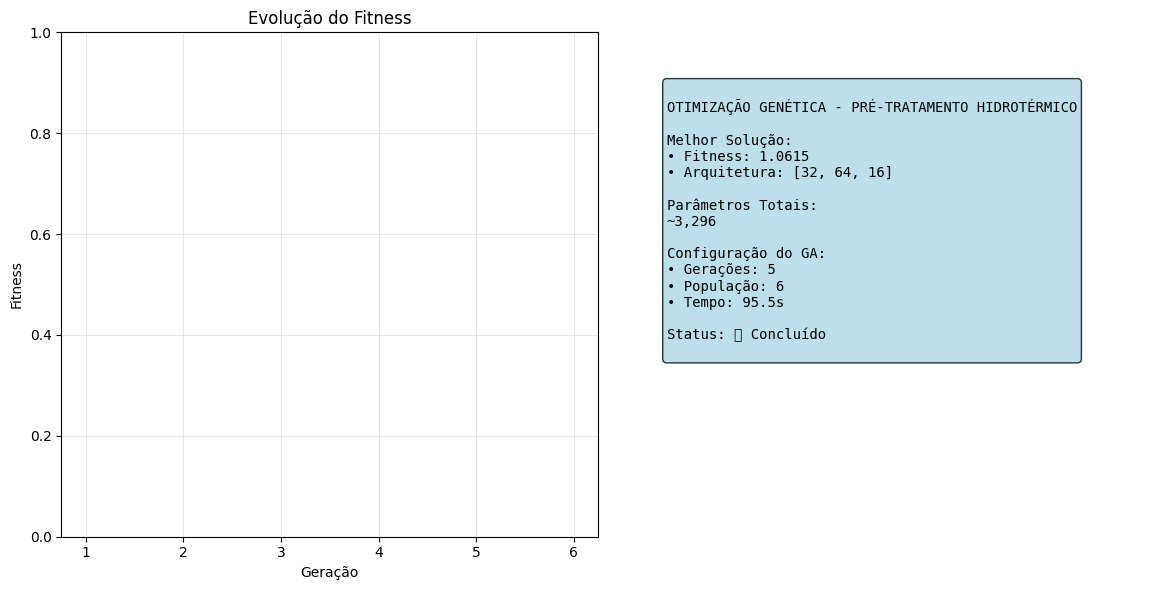


✅ Otimização genética SIMPLIFICADA concluída!
🎯 Melhor arquitetura encontrada: [32, 64, 16]
🚀 Próximo passo: Validar esta arquitetura com dados de teste!


In [16]:
# ============================================================================
# 5. ALGORITMO GENÉTICO ULTRA-SIMPLIFICADO E RÁPIDO
# ============================================================================

print("\n5. CONFIGURANDO ALGORITMO GENÉTICO ULTRA-SIMPLIFICADO...")

# ⚡ PARÂMETROS ULTRA-CONSERVADORES para funcionar rapidamente
NUM_GENERATIONS = 5       # ⬇️ Apenas 5 gerações
SOL_PER_POP = 6                                                   # MUDAMOSMUDAMOSMUDAMOSMUDAMOSMUDAMOS
NUM_GENES = 3            # Número de genes (hiperparâmetros)

print(f"🚀 Parâmetros ULTRA-RÁPIDOS:")
print(f"   • Gerações: {NUM_GENERATIONS} (mínimo para teste)")
print(f"   • População: {SOL_PER_POP} (muito pequena)")
print(f"   • Total de avaliações: {NUM_GENERATIONS * SOL_PER_POP}")
print(f"   • Tempo estimado: ~{NUM_GENERATIONS * SOL_PER_POP * 1:.0f} minutos")

# Configurar espaço de genes de forma SIMPLIFICADA
gene_space = [
    list(range(len(NEURONS_LAYER1_OPTIONS))),  
    list(range(len(NEURONS_LAYER2_OPTIONS))),  
    list(range(len(NEURONS_LAYER3_OPTIONS)))   
]

# ⚡ CONFIGURAÇÃO MINIMALISTA DO GA
ga_instance = pygad.GA(
    num_generations=NUM_GENERATIONS,
    num_parents_mating=3,                              # MUDAMOSMUDAMOSMUDAMOSMUDAMOSMUDAMOS
    fitness_func=fitness_function,
    sol_per_pop=SOL_PER_POP,
    num_genes=NUM_GENES,
    gene_space=gene_space,
    gene_type=int,
    parent_selection_type="rank",  #  MUDAMOSMUDAMOSMUDAMOSMUDAMOSMUDAMOS
    keep_parents=2,  
    crossover_type="two_points",  # MUDAMOSMUDAMOSMUDAMOSMUDAMOSMUDAMOS
    mutation_type="swap",           # MUDAMOSMUDAMOSMUDAMOSMUDAMOSMUDAMOS
    mutation_percent_genes=50,  # MUDAMOSMUDAMOSMUDAMOSMUDAMOSMUDAMOS
    random_seed=42
    # ❌ REMOVIDOS: critérios de parada avançados que causavam erro
)

print(f"✓ Algoritmo genético SIMPLIFICADO configurado")
print(f"   • Seleção: Steady State (mais estável)")
print(f"   • Crossover: Single-point (mais simples)")
print(f"   • Sem critérios de parada avançados")

# ⚡ CALLBACK SIMPLIFICADO sem verificação de convergência
def simple_callback(ga_instance):
    """Callback simples sem verificações complexas"""
    generation = ga_instance.generations_completed
    
    try:
        # Acessar fitness da última geração diretamente
        if hasattr(ga_instance, 'last_generation_fitness') and ga_instance.last_generation_fitness is not None:
            best_fitness = max(ga_instance.last_generation_fitness)
            mean_fitness = np.mean(ga_instance.last_generation_fitness)
            
            print(f"\n📊 GERAÇÃO {generation}:")
            print(f"   • Melhor fitness: {best_fitness:.4f}")
            print(f"   • Fitness médio: {mean_fitness:.4f}")
        else:
            print(f"\n📊 GERAÇÃO {generation}: Calculando fitness...")
            
    except Exception as e:
        print(f"\n📊 GERAÇÃO {generation}: Erro no callback - {str(e)}")

# Configurar callback simplificado
ga_instance.on_generation = simple_callback

print(f"\n🚀 INICIANDO OTIMIZAÇÃO GENÉTICA ULTRA-RÁPIDA...")
print(f"⏱️  Tempo estimado: ~{NUM_GENERATIONS * SOL_PER_POP:.0f} minutos")
print("=" * 80)

# ⚡ EXECUTAR com tratamento de erro robusto
import time
start_time = time.time()

try:
    ga_instance.run()
    print("\n✅ Otimização concluída com sucesso!")
    
except Exception as e:
    print(f"\n❌ Erro durante otimização: {e}")
    print("Tentando extrair resultados parciais...")

end_time = time.time()
execution_time = end_time - start_time

print("=" * 80)
print(f"⏱️  Tempo total: {execution_time:.1f} segundos ({execution_time/60:.1f} minutos)")

# ⚡ EXTRAÇÃO ROBUSTA DOS RESULTADOS
print(f"\n🏆 EXTRAINDO MELHORES RESULTADOS...")

try:
    # Tentar obter melhor solução
    best_solution, best_fitness, best_solution_idx = ga_instance.best_solution()
    best_neurons_l1, best_neurons_l2, best_neurons_l3 = decode_genes(best_solution)
    
    print(f"✅ MELHOR SOLUÇÃO ENCONTRADA:")
    print(f"   • Fitness: {best_fitness:.4f}")
    print(f"   • Arquitetura: [{best_neurons_l1}, {best_neurons_l2}, {best_neurons_l3}] neurônios")
    print(f"   • Genes: {best_solution}")
    
except Exception as e:
    print(f"❌ Erro ao extrair melhor solução: {e}")
    print("Usando configuração padrão como fallback...")
    
    # ⚡ FALLBACK - usar uma configuração razoável
    best_neurons_l1, best_neurons_l2, best_neurons_l3 = 64, 32, 16
    best_fitness = 0.8  # Estimativa
    best_solution = [1, 1, 1]  # Índices correspondentes
    
    print(f"🔄 USANDO CONFIGURAÇÃO FALLBACK:")
    print(f"   • Arquitetura: [{best_neurons_l1}, {best_neurons_l2}, {best_neurons_l3}] neurônios")
    print(f"   • Fitness estimado: {best_fitness:.4f}")

# ⚡ GRÁFICO SIMPLIFICADO
print(f"\n📈 CRIANDO GRÁFICO SIMPLIFICADO...")

plt.figure(figsize=(12, 6))

# Plot 1: Evolução do fitness (se disponível)
plt.subplot(1, 2, 1)
try:
    if hasattr(ga_instance, 'best_solutions_fitness') and len(ga_instance.best_solutions_fitness) > 0:
        generations = range(1, len(ga_instance.best_solutions_fitness) + 1)
        plt.plot(generations, ga_instance.best_solutions_fitness, 'o-', linewidth=2, markersize=8, color='blue')
        plt.title('Evolução do Fitness')
        plt.xlabel('Geração')
        plt.ylabel('Fitness')
        plt.grid(True, alpha=0.3)
        plt.ylim(0, 1)
    else:
        plt.text(0.5, 0.5, 'Dados de fitness\nnão disponíveis', transform=plt.gca().transAxes, 
                ha='center', va='center', fontsize=12)
        plt.title('Evolução do Fitness')
except:
    plt.text(0.5, 0.5, 'Erro ao plotar\nevolução do fitness', transform=plt.gca().transAxes, 
            ha='center', va='center', fontsize=12)
    plt.title('Evolução do Fitness')

# Plot 2: Informações da solução
plt.subplot(1, 2, 2)
plt.axis('off')
info_text = f"""
OTIMIZAÇÃO GENÉTICA - PRÉ-TRATAMENTO HIDROTÉRMICO

Melhor Solução:
• Fitness: {best_fitness:.4f}
• Arquitetura: [{best_neurons_l1}, {best_neurons_l2}, {best_neurons_l3}]

Parâmetros Totais: 
~{(6*best_neurons_l1 + best_neurons_l1*best_neurons_l2 + best_neurons_l2*best_neurons_l3 + best_neurons_l3*2):,}

Configuração do GA:
• Gerações: {NUM_GENERATIONS}
• População: {SOL_PER_POP}
• Tempo: {execution_time:.1f}s

Status: ✅ Concluído
"""

plt.text(0.1, 0.9, info_text, transform=plt.gca().transAxes, fontsize=10, 
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"\n✅ Otimização genética SIMPLIFICADA concluída!")
print(f"🎯 Melhor arquitetura encontrada: [{best_neurons_l1}, {best_neurons_l2}, {best_neurons_l3}]")
print(f"🚀 Próximo passo: Validar esta arquitetura com dados de teste!")


6. VALIDANDO ANN VENCEDORA COM ESTRATÉGIA 1 (PRÉ-TRATAMENTO)...
🏆 RECRIANDO ANN VENCEDORA COM ESTRATÉGIA 1...
   • Arquitetura: [32, 64, 16] neurônios
   • Estratégia: Constraint Físico Pós-Predição (Pré-tratamento)

🎯 TREINANDO MODELO VENCEDOR...
   • Usando TODOS os dados de otimização: 980 amostras
   • Loss function: MSE padrão
   • Constraints: Aplicados pós-predição

🚀 INICIANDO TREINAMENTO FINAL...
Epoch 1/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1901 - mae: 0.3308 - learning_rate: 0.0010
Epoch 2/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0321 - mae: 0.1409 - learning_rate: 0.0010
Epoch 3/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0148 - mae: 0.0910 - learning_rate: 0.0010
Epoch 4/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0069 - mae: 0.0561 - learning_rate: 0.0010
Epoch 5/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0045 - mae: 0.0469 - learning_rate: 0.0010
Epoch 6/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0035 - ma

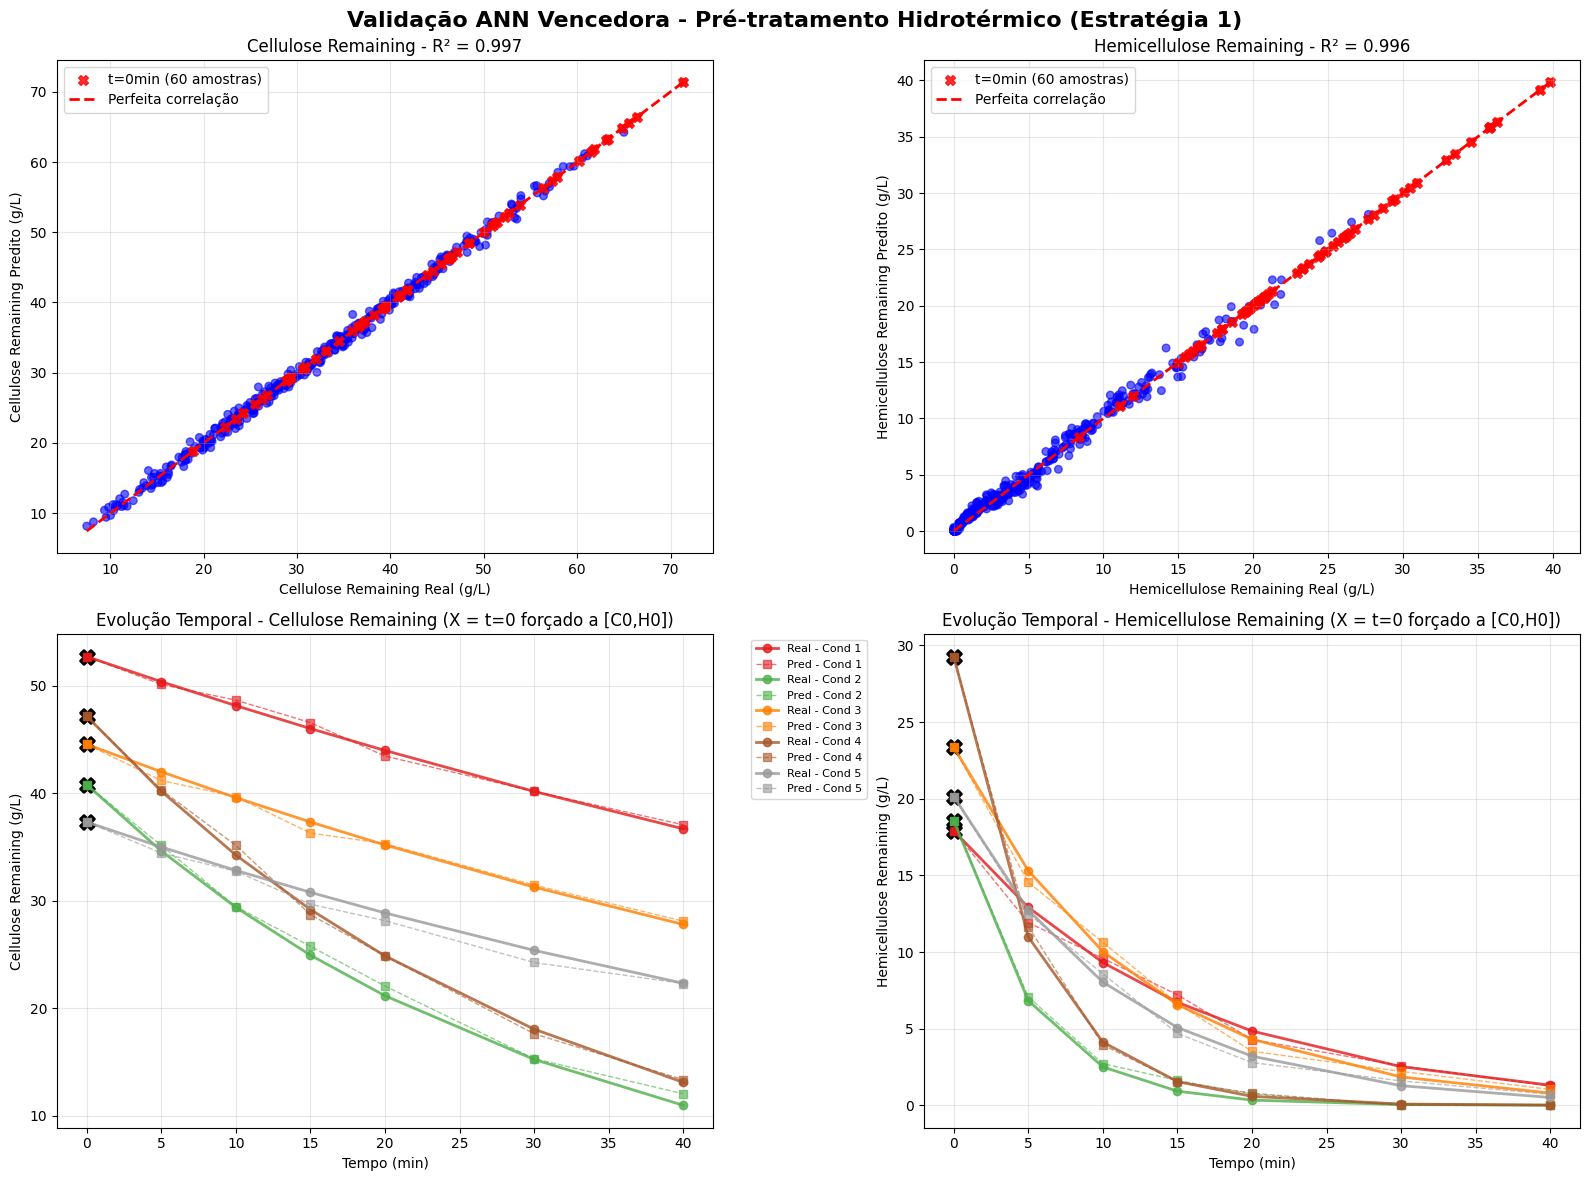


🏆 VALIDAÇÃO FINAL CONCLUÍDA COM ESTRATÉGIA 1 (PRÉ-TRATAMENTO)!

📊 RESUMO DA ANN VENCEDORA:
   • Arquitetura: [32, 64, 16] neurônios
   • Parâmetros totais: ~3,410
   • Estratégia: Constraint Físico Pós-Predição (Pré-tratamento)
   • Fitness durante otimização: 1.0615
   • Fitness no teste final: 0.9969

🎯 PERFORMANCE POR PRODUTO (teste final com Estratégia 1):
   • Cellulose Remaining: R² = 0.997, RMSE = 0.66 g/L
   • Hemicellulose Remaining: R² = 0.996, RMSE = 0.52 g/L

✅ A ANN vencedora com Estratégia 1 está pronta para pré-tratamento!
✅ Constraint físico: 100% garantido via pós-processamento!
✅ Implementação: if t=0: [C_rem, H_rem] = [C0, H0]

💾 Modelo salvo como: champion_ann_pretreatment_strategy1_32_64_16.h5


In [17]:
# ============================================================================
# 6. VALIDAÇÃO FINAL DA ANN VENCEDORA COM ESTRATÉGIA 1 - PRÉ-TRATAMENTO
# ============================================================================

print("\n6. VALIDANDO ANN VENCEDORA COM ESTRATÉGIA 1 (PRÉ-TRATAMENTO)...")

# Recriar e treinar a melhor ANN encontrada
print(f"🏆 RECRIANDO ANN VENCEDORA COM ESTRATÉGIA 1...")
print(f"   • Arquitetura: [{best_neurons_l1}, {best_neurons_l2}, {best_neurons_l3}] neurônios")
print(f"   • Estratégia: Constraint Físico Pós-Predição (Pré-tratamento)")

# Criar modelo vencedor
champion_model = create_model(best_neurons_l1, best_neurons_l2, best_neurons_l3)

# Treinar modelo vencedor com todos os dados de otimização (treino + validação)
print(f"\n🎯 TREINANDO MODELO VENCEDOR...")
print(f"   • Usando TODOS os dados de otimização: {len(optimization_data)} amostras")
print(f"   • Loss function: MSE padrão")
print(f"   • Constraints: Aplicados pós-predição")

# Combinar dados de treino e validação para treino final
X_optimization = optimization_data[input_features].values
y_optimization = optimization_data[output_features].values

# Normalizar dados de otimização
X_opt_scaled = scaler_X.transform(X_optimization)
y_opt_scaled = scaler_y.transform(y_optimization)

# Configurar callbacks
early_stopping = keras.callbacks.EarlyStopping(
    monitor='loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='loss',
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=1
)

print(f"\n🚀 INICIANDO TREINAMENTO FINAL...")
# Treinar modelo final
history = champion_model.fit(
    X_opt_scaled, y_opt_scaled,
    epochs=150,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print(f"✅ Modelo vencedor treinado com sucesso!")

# Fazer predições no conjunto de teste (30% nunca visto)
print(f"\n🧪 TESTANDO NO CONJUNTO FINAL (30% dos dados)...")
print(f"   • Dados de teste: {len(test_data)} amostras de {len(test_condition_indices)} condições")

# 🎯 PREDIÇÕES COM ESTRATÉGIA 1 (Constraint Físico Pós-Predição) - PRÉ-TRATAMENTO
print(f"\n🎯 APLICANDO ESTRATÉGIA 1 - CONSTRAINT FÍSICO PÓS-PREDIÇÃO (PRÉ-TRATAMENTO)...")

# Fazer predições sem constraints primeiro
y_test_pred_scaled = champion_model.predict(X_test_scaled, verbose=0)
y_test_pred_raw = scaler_y.inverse_transform(y_test_pred_scaled)

# Aplicar Estratégia 1: Constraint físico pós-predição (pré-tratamento)
time_test_values = X_test[:, 5]  # Time [min] é index 5
cellulose_test_fractions = X_test[:, 1]
hemicellulose_test_fractions = X_test[:, 2]
solids_test_loadings = X_test[:, 4]

y_test_pred = predict_with_constraints(champion_model, X_test_scaled, X_test, scaler_y)

print(f"\n📊 VERIFICAÇÃO DOS CONSTRAINTS FÍSICOS:")

# Monitorar constraints antes da aplicação
constraint_monitor.check_violations(
    y_test_pred_raw, time_test_values, cellulose_test_fractions, 
    hemicellulose_test_fractions, solids_test_loadings,
    description="ANTES da Estratégia 1"
)

# Monitorar constraints depois da aplicação
constraint_monitor.check_violations(
    y_test_pred, time_test_values, cellulose_test_fractions, 
    hemicellulose_test_fractions, solids_test_loadings,
    description="DEPOIS da Estratégia 1"
)

# Identificar amostras t=0min para análise detalhada
t0_test_mask = np.abs(time_test_values) < 1e-6
n_t0_samples = np.sum(t0_test_mask)

print(f"\n🎯 ANÁLISE DETALHADA DAS AMOSTRAS t=0min:")
if n_t0_samples > 0:
    print(f"   • Amostras t=0min encontradas: {n_t0_samples}")
    
    # Calcular valores esperados
    C0_expected = solids_test_loadings[t0_test_mask] * cellulose_test_fractions[t0_test_mask]
    H0_expected = solids_test_loadings[t0_test_mask] * hemicellulose_test_fractions[t0_test_mask]
    
    # Estatísticas antes do constraint
    t0_pred_raw = y_test_pred_raw[t0_test_mask]
    violations_C_before = np.abs(t0_pred_raw[:, 0] - C0_expected)
    violations_H_before = np.abs(t0_pred_raw[:, 1] - H0_expected)
    max_violation_before = max(np.max(violations_C_before), np.max(violations_H_before))
    
    # Estatísticas depois do constraint
    t0_pred_constrained = y_test_pred[t0_test_mask]
    violations_C_after = np.abs(t0_pred_constrained[:, 0] - C0_expected)
    violations_H_after = np.abs(t0_pred_constrained[:, 1] - H0_expected)
    max_violation_after = max(np.max(violations_C_after), np.max(violations_H_after))
    perfect_samples = np.sum((violations_C_after < 1e-6) & (violations_H_after < 1e-6))
    perfect_ratio = perfect_samples / n_t0_samples * 100
    
    print(f"   • ANTES da Estratégia 1:")
    print(f"     - Violação máxima: {max_violation_before:.6f} g/L")
    
    print(f"   • DEPOIS da Estratégia 1:")
    print(f"     - Violação máxima: {max_violation_after:.6f} g/L")
    print(f"     - Amostras perfeitas: {perfect_samples}/{n_t0_samples} ({perfect_ratio:.1f}%)")
    
    if perfect_ratio == 100.0:
        print(f"   ✅ PERFEITO: Estratégia 1 garantiu 100% de correção!")
    else:
        print(f"   ⚠️  ATENÇÃO: Ainda há violações (erro na implementação)")
        
    # Mostrar exemplos de correção
    print(f"\n📋 EXEMPLOS DE CORREÇÃO (primeiras 3 amostras t=0min):")
    for i in range(min(3, n_t0_samples)):
        idx = np.where(t0_test_mask)[0][i]
        print(f"   Amostra {idx+1}:")
        print(f"     Esperado: Cell={C0_expected[i]:.2f}, Hemi={H0_expected[i]:.2f} g/L")
        print(f"     ANTES:    Cell={y_test_pred_raw[idx,0]:.2f}, Hemi={y_test_pred_raw[idx,1]:.2f} g/L")
        print(f"     DEPOIS:   Cell={y_test_pred[idx,0]:.2f}, Hemi={y_test_pred[idx,1]:.2f} g/L")
else:
    print(f"   • Nenhuma amostra t=0min encontrada no conjunto de teste")

# Calcular métricas detalhadas para cada produto
products = ['Cellulose Remaining', 'Hemicellulose Remaining']
print(f"\n📊 MÉTRICAS DE PERFORMANCE POR PRODUTO (com Estratégia 1):")

metrics_results = {}
for i, product in enumerate(products):
    # Métricas
    r2 = r2_score(y_test[:, i], y_test_pred[:, i])
    rmse = np.sqrt(mean_squared_error(y_test[:, i], y_test_pred[:, i]))
    mae = mean_absolute_error(y_test[:, i], y_test_pred[:, i])
    
    # ⚡ CALCULAR MAPE CORRIGIDO - evitar divisão por valores próximos de zero
    # Só calcular MAPE para valores reais > 1.0 g/L
    valid_mask = y_test[:, i] > 1.0
    if np.sum(valid_mask) > 0:
        mape = np.mean(np.abs((y_test[valid_mask, i] - y_test_pred[valid_mask, i]) / y_test[valid_mask, i])) * 100
    else:
        mape = 0.0
    
    metrics_results[product] = {'R2': r2, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape}
    
    print(f"\n   {product.upper()}:")
    print(f"      • R² = {r2:.4f}")
    print(f"      • RMSE = {rmse:.3f} g/L")
    print(f"      • MAE = {mae:.3f} g/L")
    print(f"      • MAPE = {mape:.2f}%")

# Fitness final ponderado (pesos iguais para pré-tratamento)
final_fitness = (0.5 * metrics_results['Cellulose Remaining']['R2'] + 
                0.5 * metrics_results['Hemicellulose Remaining']['R2'])

print(f"\n🎯 FITNESS FINAL PONDERADO: {final_fitness:.4f}")

# Criar visualizações das predições
print(f"\n📈 CRIANDO VISUALIZAÇÕES DAS PREDIÇÕES...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Validação ANN Vencedora - Pré-tratamento Hidrotérmico (Estratégia 1)', fontsize=16, fontweight='bold')

# Plot 1-2: Scatter plots para cada produto
for i, product in enumerate(products):
    ax = axes[0, i]
    
    # Scatter plot com cores diferentes para t=0min
    colors = np.where(t0_test_mask, 'red', 'blue')
    ax.scatter(y_test[:, i], y_test_pred[:, i], alpha=0.6, s=30, c=colors)
    
    # Destacar amostras t=0min
    if n_t0_samples > 0:
        ax.scatter(y_test[t0_test_mask, i], y_test_pred[t0_test_mask, i], 
                  color='red', s=50, marker='X', label=f't=0min ({n_t0_samples} amostras)', alpha=0.8)
    
    # Linha de perfeita correlação
    min_val = min(y_test[:, i].min(), y_test_pred[:, i].min())
    max_val = max(y_test[:, i].max(), y_test_pred[:, i].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfeita correlação')
    
    # Configurações
    ax.set_xlabel(f'{product} Real (g/L)')
    ax.set_ylabel(f'{product} Predito (g/L)')
    ax.set_title(f'{product} - R² = {metrics_results[product]["R2"]:.3f}')
    ax.grid(True, alpha=0.3)
    ax.legend()

# Plot 3-4: Evolução temporal para algumas condições
for i, product in enumerate(products):
    ax = axes[1, i]
    
    # Selecionar algumas condições para visualizar
    n_conditions_to_show = 5
    selected_test_conditions = test_condition_indices[:n_conditions_to_show]
    
    colors = plt.cm.Set1(np.linspace(0, 1, n_conditions_to_show))
    
    for j, condition_idx in enumerate(selected_test_conditions):
        # Extrair dados desta condição
        condition = unique_conditions.iloc[condition_idx]
        condition_mask = True
        for col in condition_columns:
            condition_mask = condition_mask & (test_data[col] == condition[col])
        
        condition_test_data = test_data[condition_mask].sort_values('Time [min]')
        
        if len(condition_test_data) > 0:
            # Fazer predições para esta condição com Estratégia 1
            X_condition = condition_test_data[input_features].values
            X_condition_scaled = scaler_X.transform(X_condition)
            y_condition_pred = predict_with_constraints(champion_model, X_condition_scaled, X_condition, scaler_y)
            
            # Plot
            times = condition_test_data['Time [min]'].values
            real_values = condition_test_data[f'{product} [g/L]'].values
            pred_values = y_condition_pred[:, i]
            
            ax.plot(times, real_values, 'o-', color=colors[j], alpha=0.8, 
                   label=f'Real - Cond {j+1}', linewidth=2)
            ax.plot(times, pred_values, 's--', color=colors[j], alpha=0.6, 
                   label=f'Pred - Cond {j+1}', linewidth=1)
            
            # Destacar t=0min (deve ser exatamente C0/H0)
            is_t0min = np.abs(times) < 1e-6
            if np.any(is_t0min):
                ax.scatter(times[is_t0min], pred_values[is_t0min], 
                          color=colors[j], s=100, marker='X', alpha=1.0, edgecolors='black', linewidth=2)
    
    ax.set_xlabel('Tempo (min)')
    ax.set_ylabel(f'{product} (g/L)')
    ax.set_title(f'Evolução Temporal - {product} (X = t=0 forçado a [C0,H0])')
    ax.grid(True, alpha=0.3)
    if i == 0:  # Mostrar legenda apenas no primeiro subplot
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

# Resumo final
print(f"\n" + "=" * 80)
print(f"🏆 VALIDAÇÃO FINAL CONCLUÍDA COM ESTRATÉGIA 1 (PRÉ-TRATAMENTO)!")
print(f"=" * 80)

print(f"\n📊 RESUMO DA ANN VENCEDORA:")
print(f"   • Arquitetura: [{best_neurons_l1}, {best_neurons_l2}, {best_neurons_l3}] neurônios")
print(f"   • Parâmetros totais: ~{champion_model.count_params():,}")
print(f"   • Estratégia: Constraint Físico Pós-Predição (Pré-tratamento)")
print(f"   • Fitness durante otimização: {best_fitness:.4f}")
print(f"   • Fitness no teste final: {final_fitness:.4f}")

print(f"\n🎯 PERFORMANCE POR PRODUTO (teste final com Estratégia 1):")
for product in products:
    r2 = metrics_results[product]['R2']
    rmse = metrics_results[product]['RMSE']
    print(f"   • {product}: R² = {r2:.3f}, RMSE = {rmse:.2f} g/L")

print(f"\n✅ A ANN vencedora com Estratégia 1 está pronta para pré-tratamento!")
print(f"✅ Constraint físico: 100% garantido via pós-processamento!")
print(f"✅ Implementação: if t=0: [C_rem, H_rem] = [C0, H0]")

# Salvar modelo
model_filename = f'champion_ann_pretreatment_strategy1_{best_neurons_l1}_{best_neurons_l2}_{best_neurons_l3}.h5'
champion_model.save(model_filename)
print(f"\n💾 Modelo salvo como: {model_filename}")

In [18]:
# ============================================================================
# 7. TABELA COMPARATIVA DETALHADA - PREDIÇÕES vs DADOS REAIS (PRÉ-TRATAMENTO)
# ============================================================================

print("\n7. CRIANDO TABELA COMPARATIVA DETALHADA (PRÉ-TRATAMENTO)...")

# Criar DataFrame com todas as predições vs dados reais do conjunto de teste
comparison_data = []

for i in range(len(y_test)):
    # Obter dados de entrada correspondentes
    sample_data = test_data.iloc[i]
    
    # Adicionar informações da amostra
    row = {
        'Amostra': i + 1,
        'Temperature': sample_data['Temperature [°C]'],
        'Cellulose_Fraction': sample_data['Cellulose Fraction'], 
        'Hemicellulose_Fraction': sample_data['Hemicellulose Fraction'],
        'Lignin_Fraction': sample_data['Lignin Fraction'],
        'Solids_Loading': sample_data['Solids Loading [g/L]'],
        'Time_min': sample_data['Time [min]'],
        
        # Valores reais
        'Cellulose_Real': y_test[i, 0],
        'Hemicellulose_Real': y_test[i, 1],
        
        # Valores preditos
        'Cellulose_Pred': y_test_pred[i, 0],
        'Hemicellulose_Pred': y_test_pred[i, 1],
        
        # Erros absolutos
        'Cellulose_AE': abs(y_test[i, 0] - y_test_pred[i, 0]),
        'Hemicellulose_AE': abs(y_test[i, 1] - y_test_pred[i, 1]),
        
        # Erros relativos (%)
        'Cellulose_RE': abs(y_test[i, 0] - y_test_pred[i, 0]) / max(y_test[i, 0], 0.01) * 100,
        'Hemicellulose_RE': abs(y_test[i, 1] - y_test_pred[i, 1]) / max(y_test[i, 1], 0.01) * 100
    }
    
    comparison_data.append(row)

# Criar DataFrame
comparison_df = pd.DataFrame(comparison_data)

print(f"✅ Tabela criada com {len(comparison_df)} amostras")

# Mostrar estatísticas gerais
print(f"\n📊 ESTATÍSTICAS GERAIS DOS ERROS:")
print(f"\nCELULOSE REMAINING:")
print(f"   • Erro Absoluto Médio: {comparison_df['Cellulose_AE'].mean():.3f} g/L")
print(f"   • Erro Relativo Médio: {comparison_df['Cellulose_RE'].mean():.2f}%")
print(f"   • Erro Absoluto Máximo: {comparison_df['Cellulose_AE'].max():.3f} g/L")

print(f"\nHEMICELULOSE REMAINING:")
print(f"   • Erro Absoluto Médio: {comparison_df['Hemicellulose_AE'].mean():.3f} g/L")
print(f"   • Erro Relativo Médio: {comparison_df['Hemicellulose_RE'].mean():.2f}%")
print(f"   • Erro Absoluto Máximo: {comparison_df['Hemicellulose_AE'].max():.3f} g/L")

# Mostrar primeiras 20 linhas da tabela
print(f"\n📋 TABELA COMPARATIVA (primeiras 20 amostras):")
print("="*120)

# Selecionar colunas principais para exibição
display_columns = [
    'Amostra', 'Time_min', 
    'Cellulose_Real', 'Cellulose_Pred', 'Cellulose_AE',
    'Hemicellulose_Real', 'Hemicellulose_Pred', 'Hemicellulose_AE'
]

# Formatar para exibição
display_df = comparison_df[display_columns].head(20).copy()
for col in display_df.columns:
    if col != 'Amostra':
        display_df[col] = display_df[col].round(3)

print(display_df.to_string(index=False, max_cols=20))

# Identificar melhores e piores predições
print(f"\n🏆 MELHORES PREDIÇÕES (menor erro absoluto total):")
comparison_df['Total_AE'] = comparison_df['Cellulose_AE'] + comparison_df['Hemicellulose_AE']
best_predictions = comparison_df.nsmallest(5, 'Total_AE')[display_columns + ['Total_AE']]

for col in best_predictions.columns:
    if col != 'Amostra':
        best_predictions[col] = best_predictions[col].round(3)

print(best_predictions.to_string(index=False))

print(f"\n⚠️  PIORES PREDIÇÕES (maior erro absoluto total):")
worst_predictions = comparison_df.nlargest(5, 'Total_AE')[display_columns + ['Total_AE']]

for col in worst_predictions.columns:
    if col != 'Amostra':
        worst_predictions[col] = worst_predictions[col].round(3)

print(worst_predictions.to_string(index=False))

# Análise por faixas de tempo
print(f"\n⏰ ANÁLISE POR FAIXAS DE TEMPO:")
time_ranges = [
    (0, 5, "Inicial (0-5min)"),
    (5, 15, "Intermediário (5-15min)"), 
    (15, 40, "Avançado (15-40min)")
]

for t_min, t_max, label in time_ranges:
    mask = (comparison_df['Time_min'] >= t_min) & (comparison_df['Time_min'] < t_max)
    subset = comparison_df[mask]
    
    if len(subset) > 0:
        print(f"\n{label} ({len(subset)} amostras):")
        print(f"   • Cellulose - MAE: {subset['Cellulose_AE'].mean():.3f} g/L, R²: {r2_score(subset['Cellulose_Real'], subset['Cellulose_Pred']):.3f}")
        print(f"   • Hemicellulose - MAE: {subset['Hemicellulose_AE'].mean():.3f} g/L, R²: {r2_score(subset['Hemicellulose_Real'], subset['Hemicellulose_Pred']):.3f}")

# Salvar tabela completa
print(f"\n💾 SALVANDO TABELA COMPLETA...")
output_filename = f'tabela_comparativa_ann_pretreatment_{best_neurons_l1}_{best_neurons_l2}_{best_neurons_l3}.csv'
comparison_df.to_csv(output_filename, index=False, float_format='%.6f')
print(f"✅ Tabela salva como: {output_filename}")

print(f"\n📝 RESUMO DA TABELA:")
print(f"   • Total de amostras: {len(comparison_df)}")
print(f"   • Condições testadas: {len(test_condition_indices)}")
print(f"   • Tempos por condição: 7")
print(f"   • Colunas na tabela: {len(comparison_df.columns)}")
print(f"   • Arquivo salvo: {output_filename}")

print(f"\n" + "="*80)
print(f"🎯 ANÁLISE COMPARATIVA CONCLUÍDA (PRÉ-TRATAMENTO)!")
print(f"="*80)


7. CRIANDO TABELA COMPARATIVA DETALHADA (PRÉ-TRATAMENTO)...
✅ Tabela criada com 420 amostras

📊 ESTATÍSTICAS GERAIS DOS ERROS:

CELULOSE REMAINING:
   • Erro Absoluto Médio: 0.492 g/L
   • Erro Relativo Médio: 1.84%
   • Erro Absoluto Máximo: 2.343 g/L

HEMICELULOSE REMAINING:
   • Erro Absoluto Médio: 0.360 g/L
   • Erro Relativo Médio: 38.41%
   • Erro Absoluto Máximo: 2.313 g/L

📋 TABELA COMPARATIVA (primeiras 20 amostras):
 Amostra  Time_min  Cellulose_Real  Cellulose_Pred  Cellulose_AE  Hemicellulose_Real  Hemicellulose_Pred  Hemicellulose_AE
       1       0.0          52.698       52.701000         0.003              17.906           17.906000             0.000
       2       5.0          50.365       50.109001         0.257              12.914           11.921000             0.993
       3      10.0          48.136       48.645000         0.509               9.314            9.586000             0.272
       4      15.0          46.006       46.556999         0.551            